# Rule Bias Analysis
Visualises the proportional directional rule bias `b_{src,tgt,s}` used to train the local TD3 agent.

**Sections**
1. Formula reference & parameter table  
2. Old (binary) vs new (proportional) — side-by-side heatmap  
3. Per-slice sensitivity heatmaps  
4. Net signal `tau = 0.5*(b_ij - b_ji)`  
5. Live episode trace — bias, load, and tau over time  
6. Scenario catalogue — bias distribution across training scenarios

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from local_a3_training_env import LocalA3RuleBiasTrainingEnv

## 1. Formula reference

```
diff   = src_load - tgt_load
raw    = -diff / scale
value  = clip(raw, -1, 1)     if |diff| >= deadband  and  NOT (raw<0 and src_load<min_src)
       = 0                     otherwise
```

| Slice | scale | deadband | min_src | notes |
|-------|-------|----------|---------|-------|
| eMBB  | 0.35  | 0.10     | 0.40    | baseline |
| URLLC | 0.25  | 0.07     | 0.35    | tighter — reacts faster |
| mMTC  | 0.40  | 0.12     | 0.45    | looser — more conservative |

In [2]:
PARAMS = {
    'eMBB':  {'scale': 0.35, 'deadband': 0.10, 'min_src': 0.40},
    'URLLC': {'scale': 0.25, 'deadband': 0.07, 'min_src': 0.35},
    'mMTC':  {'scale': 0.40, 'deadband': 0.12, 'min_src': 0.45},
}

def new_bias(src_load, tgt_load, slice_type):
    p = PARAMS[slice_type]
    diff = src_load - tgt_load
    if abs(diff) < p['deadband']:
        return 0.0
    raw = -diff / p['scale']
    if raw < 0.0 and src_load < p['min_src']:
        return 0.0
    return float(np.clip(raw, -1.0, 1.0))

def old_bias(src_load, tgt_load):
    if src_load > 0.75 and tgt_load < 0.75:
        return -1.0
    elif src_load < 0.45:
        return 1.0
    return 0.0

loads = np.linspace(0, 1, 200)
# indexing='ij': SRC[i,j]=loads[i] (varies with rows=y-axis=src_load)
#                TGT[i,j]=loads[j] (varies with cols=x-axis=tgt_load)
SRC, TGT = np.meshgrid(loads, loads, indexing='ij')

## 2. Old (binary) vs new (proportional)

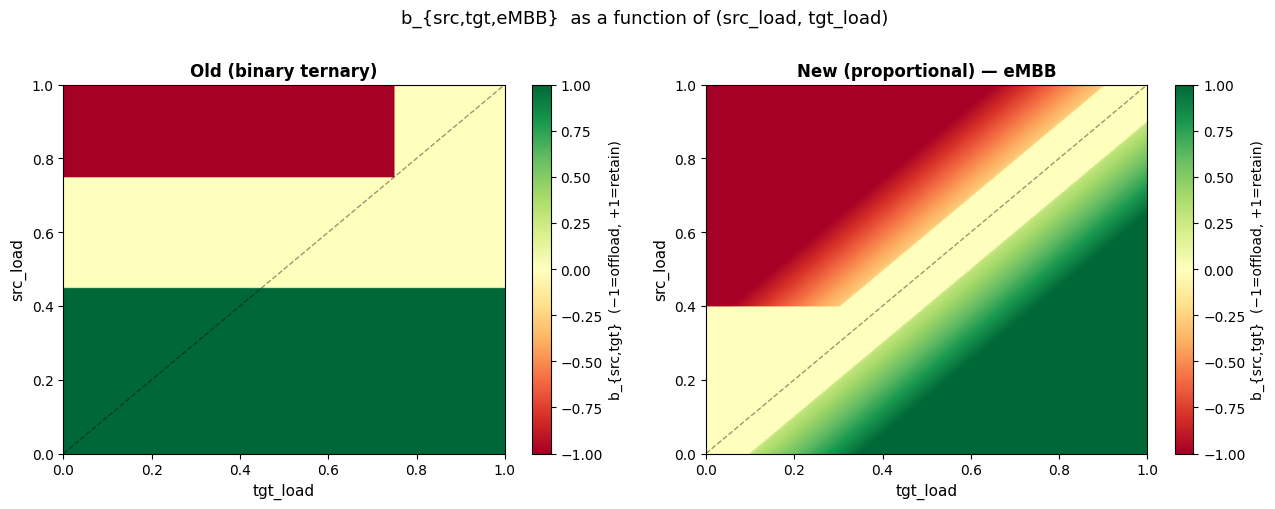

In [3]:
# Vectorise
OLD = np.vectorize(old_bias)(SRC, TGT)
NEW = np.vectorize(lambda s,t: new_bias(s,t,'eMBB'))(SRC, TGT)

cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title in zip(axes, [OLD, NEW], ['Old (binary ternary)', 'New (proportional) — eMBB']):
    im = ax.imshow(data, origin='lower', extent=[0,1,0,1],
                   cmap=cmap, norm=norm, aspect='auto')
    ax.set_xlabel('tgt_load', fontsize=11)
    ax.set_ylabel('src_load', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='b_{src,tgt}  (−1=offload, +1=retain)')
    # Diagonal
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='src=tgt')

plt.suptitle('b_{src,tgt,eMBB}  as a function of (src_load, tgt_load)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Difference map — how much the rule changed

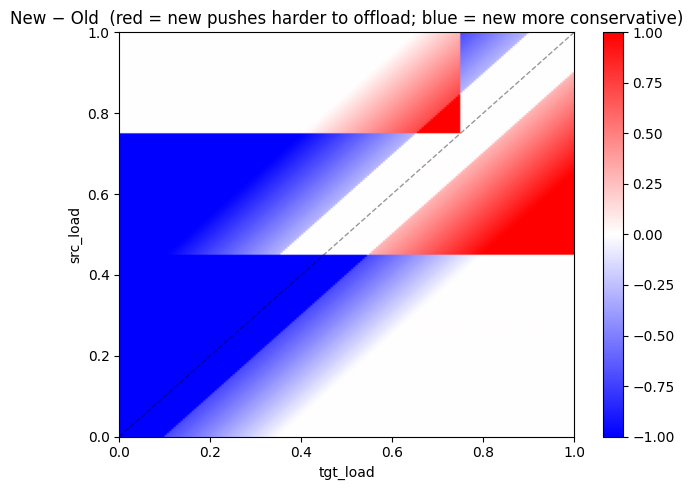

In [4]:
DIFF = NEW - OLD

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(DIFF, origin='lower', extent=[0,1,0,1],
               cmap='bwr', norm=mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),
               aspect='auto')
ax.set_xlabel('tgt_load'); ax.set_ylabel('src_load')
ax.set_title('New − Old  (red = new pushes harder to offload; blue = new more conservative)')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 3. Per-slice sensitivity heatmaps

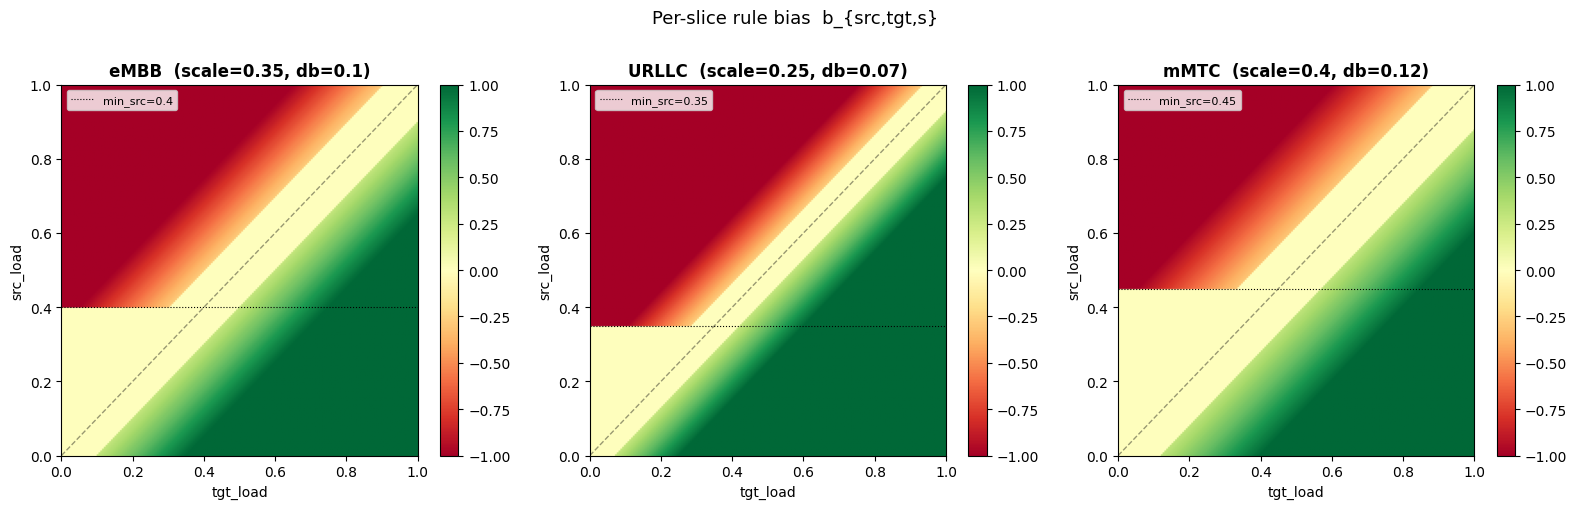

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, st in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    Z = np.vectorize(lambda s,t: new_bias(s,t,st))(SRC, TGT)
    im = ax.imshow(Z, origin='lower', extent=[0,1,0,1],
                   cmap=cmap, norm=norm, aspect='auto')
    ax.set_xlabel('tgt_load'); ax.set_ylabel('src_load')
    ax.set_title(f'{st}  (scale={PARAMS[st]["scale"]}, db={PARAMS[st]["deadband"]})',
                 fontweight='bold')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
    plt.colorbar(im, ax=ax)
    # Annotate thresholds
    ax.axhline(PARAMS[st]['min_src'], color='k', lw=0.8, ls=':', label=f'min_src={PARAMS[st]["min_src"]}')
    ax.legend(fontsize=8)

plt.suptitle('Per-slice rule bias  b_{src,tgt,s}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Cross-section: fix src_load=0.80, vary tgt_load

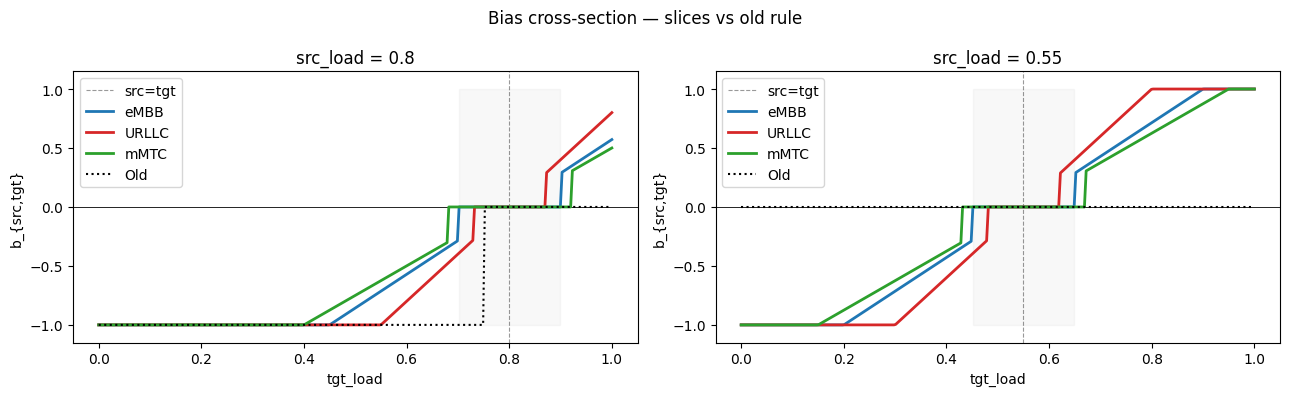

In [6]:
tgt_range = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, src_fixed in zip(axes, [0.80, 0.55]):
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(src_fixed, color='k', lw=0.8, ls='--', alpha=0.4, label='src=tgt')
    for st, color in zip(['eMBB','URLLC','mMTC'], ['#1f77b4','#d62728','#2ca02c']):
        vals = [new_bias(src_fixed, t, st) for t in tgt_range]
        ax.plot(tgt_range, vals, label=st, color=color, lw=2)
    old_vals = [old_bias(src_fixed, t) for t in tgt_range]
    ax.plot(tgt_range, old_vals, 'k:', lw=1.5, label='Old')
    ax.set_xlabel('tgt_load'); ax.set_ylabel('b_{src,tgt}')
    ax.set_title(f'src_load = {src_fixed}')
    ax.set_ylim(-1.15, 1.15); ax.legend()
    ax.fill_between(tgt_range, -1, 1, where=[abs(new_bias(src_fixed,t,'eMBB'))==0 for t in tgt_range],
                    alpha=0.05, color='gray', label='deadband (eMBB)')

plt.suptitle('Bias cross-section — slices vs old rule', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Net directional signal  `tau = 0.5 * (b_ij − b_ji)`

This is what the local TD3 observation uses after receiving the upper bias.

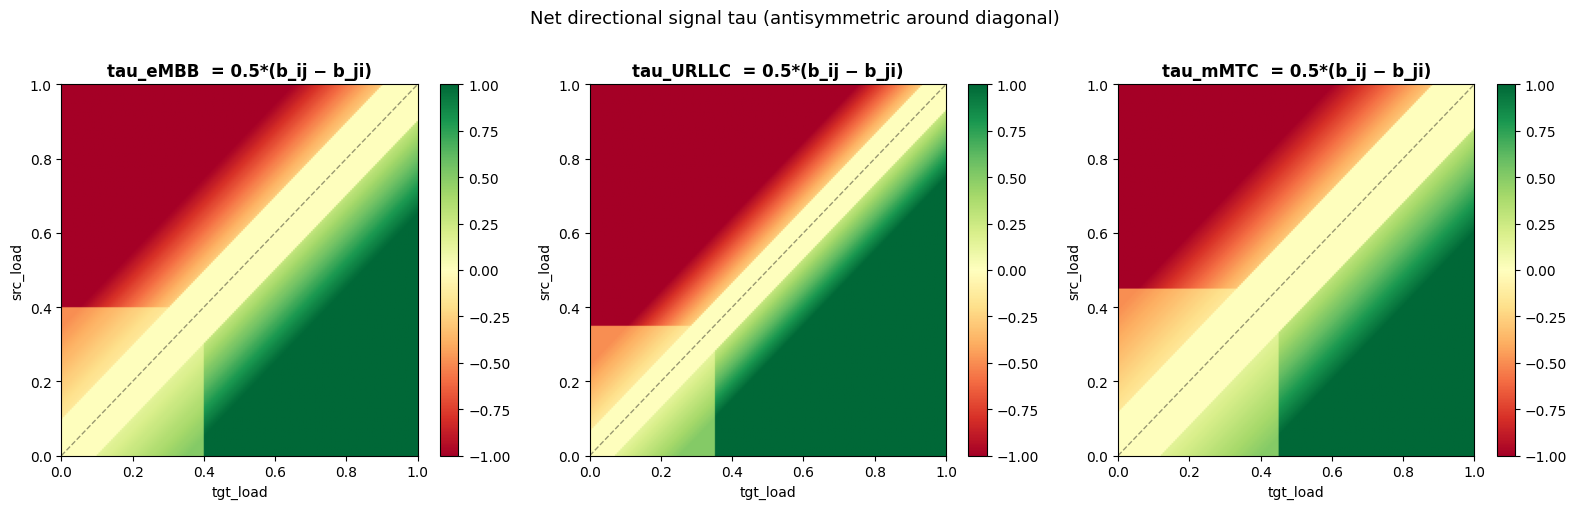

In [7]:
def tau(src_load, tgt_load, st):
    b_ij = new_bias(src_load, tgt_load, st)
    b_ji = new_bias(tgt_load, src_load, st)
    return float(np.clip(0.5 * (b_ij - b_ji), -1.0, 1.0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, st in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    Z = np.vectorize(lambda s,t: tau(s,t,st))(SRC, TGT)
    im = ax.imshow(Z, origin='lower', extent=[0,1,0,1],
                   cmap=cmap, norm=norm, aspect='auto')
    ax.set_xlabel('tgt_load'); ax.set_ylabel('src_load')
    ax.set_title(f'tau_{st}  = 0.5*(b_ij − b_ji)', fontweight='bold')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
    plt.colorbar(im, ax=ax)

plt.suptitle('Net directional signal tau (antisymmetric around diagonal)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Live episode trace — bias, load, and tau over time

In [8]:
env = LocalA3RuleBiasTrainingEnv()

def run_episode(env, seed=0):
    np.random.seed(seed)
    obs, _ = env.reset()
    history = []
    done = False
    step_idx = 0
    while not done:
        obs, rew, term, trunc, info = env.step(np.zeros(env.action_space.shape))
        done = term or trunc
        step_idx += 1

        bias = dict(env._rule_bias())
        gnb_ids = [int(g.id) for g in env.base_env.gnbs]
        loads = {(gi, s): env.base_env.estimate_slice_load(gi, s)
                 for gi in gnb_ids for s in env.slice_types}

        history.append({'step': step_idx, 'reward': rew, 'loads': loads, 'bias': bias})

    scen_name = env._current_scenario.name if env._current_scenario else 'unknown'
    return history, scen_name

history, scenario_name = run_episode(env, seed=7)
print(f'Episode: {scenario_name}  |  steps: {len(history)}')
print(f'Slice types: {env.slice_types}')

[LocalA3 scenario] reset=1 name=urllc_offload_embb_neutral_mmtc_retain cases=[eMBB=neutral] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
Episode: urllc_offload_embb_neutral_mmtc_retain  |  steps: 40
Slice types: ('eMBB',)


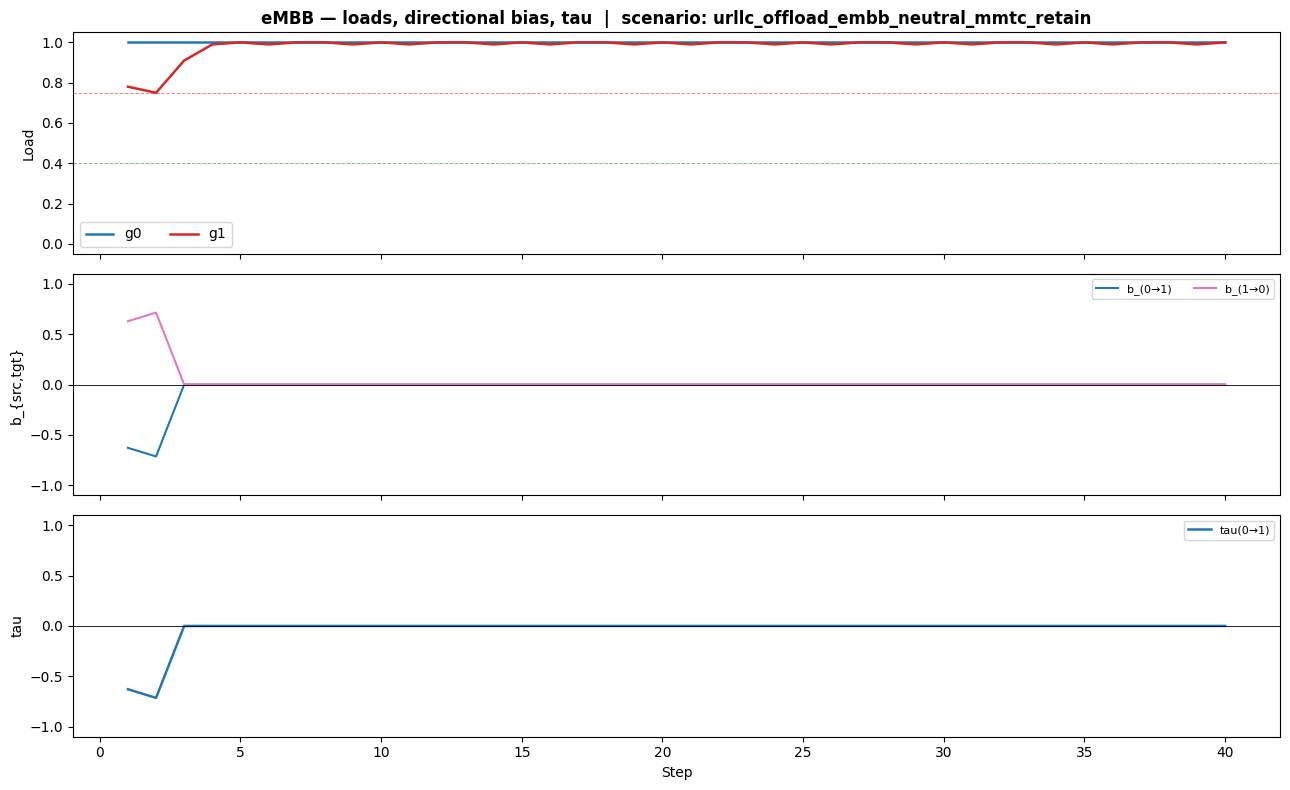

In [9]:
gnb_ids = [int(g.id) for g in env.base_env.gnbs]
slice_types = list(env.slice_types)
steps = [h['step'] for h in history]

# Build time series
def ts_load(g, s):
    return [h['loads'].get((g, s), 0.0) for h in history]

def ts_bias(src, tgt, s):
    return [h['bias'].get((src, tgt, s), 0.0) for h in history]

def ts_tau(src, tgt, s):
    return [0.5*(h['bias'].get((src,tgt,s),0)-h['bias'].get((tgt,src,s),0)) for h in history]

for st in slice_types:
    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

    # Load
    ax = axes[0]
    for g, col in zip(gnb_ids, ['#1f77b4','#d62728','#2ca02c']):
        ax.plot(steps, ts_load(g, st), label=f'g{g}', color=col, lw=1.8)
    ax.set_ylabel('Load'); ax.legend(ncol=3); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{st} — loads, directional bias, tau  |  scenario: {scenario_name}',
                 fontweight='bold')
    ax.axhline(0.75, color='r', lw=0.7, ls='--', alpha=0.5, label='high threshold')
    ax.axhline(0.40, color='g', lw=0.7, ls='--', alpha=0.5, label='low threshold')

    # Directional bias b_{0,1} and b_{1,0}
    ax = axes[1]
    pairs = [(src, tgt) for src in gnb_ids for tgt in gnb_ids if src != tgt]
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(pairs)))
    for (src, tgt), col in zip(pairs, colors):
        ax.plot(steps, ts_bias(src, tgt, st),
                label=f'b_({src}→{tgt})', color=col, lw=1.5)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_ylabel('b_{src,tgt}'); ax.legend(ncol=4, fontsize=8)
    ax.set_ylim(-1.1, 1.1)

    # Tau
    ax = axes[2]
    for (src, tgt), col in zip(pairs[:len(pairs)//2], colors):
        ax.plot(steps, ts_tau(src, tgt, st),
                label=f'tau({src}→{tgt})', color=col, lw=1.8)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_ylabel('tau'); ax.set_xlabel('Step')
    ax.legend(ncol=3, fontsize=8); ax.set_ylim(-1.1, 1.1)

    plt.tight_layout()
    plt.show()

## 6. Scenario catalogue — bias distribution across training scenarios

In [10]:
env2 = LocalA3RuleBiasTrainingEnv()
n_episodes = 40

results = []
for ep in range(n_episodes):
    obs, _ = env2.reset()
    for _ in range(8):
        env2.step(np.zeros(env2.action_space.shape))
    bias = env2._rule_bias()
    vals = list(bias.values())
    scen_name = env2._current_scenario.name if env2._current_scenario else 'unknown'
    results.append({
        'scenario': scen_name,
        'bias_vals': vals,
        'mean_abs': float(np.mean(np.abs(vals))) if vals else 0,
        'min': float(min(vals)) if vals else 0,
        'max': float(max(vals)) if vals else 0,
    })

print(f'Collected {n_episodes} episodes')
all_vals = [v for r in results for v in r['bias_vals']]
print(f'All bias values: min={min(all_vals):.3f}  max={max(all_vals):.3f}  '
      f'mean={np.mean(all_vals):.3f}  std={np.std(all_vals):.3f}')
print(f'Non-zero: {sum(v!=0 for v in all_vals)}/{len(all_vals)}')

[LocalA3 scenario] reset=1 name=urllc_offload_embb_neutral_mmtc_retain cases=[eMBB=neutral] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
[LocalA3 scenario] reset=2 name=all_offload_clean cases=[eMBB=offload] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
[LocalA3 scenario] reset=3 name=urllc_offload_embb_neutral_mmtc_retain cases=[eMBB=neutral] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
[LocalA3 scenario] reset=4 name=urllc_offload_embb_neutral_mmtc_retain cases=[eMBB=neutral] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
[LocalA3 scenario] reset=5 name=risky_embb_urllc_mmtc_neutral cases=[eMBB=risky_offload] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
[LocalA3 scenario] reset=6 name=all_offload_clean cases=[eMBB=offload] loads=[g0:eMBB=0.00, g1:eMBB=0.00] bias=[g0→g1:eMBB=+0, g1→g0:eMBB=+0]
[LocalA3 scenario] reset=7 name=all_offload_clean cases=[eMBB=offlo

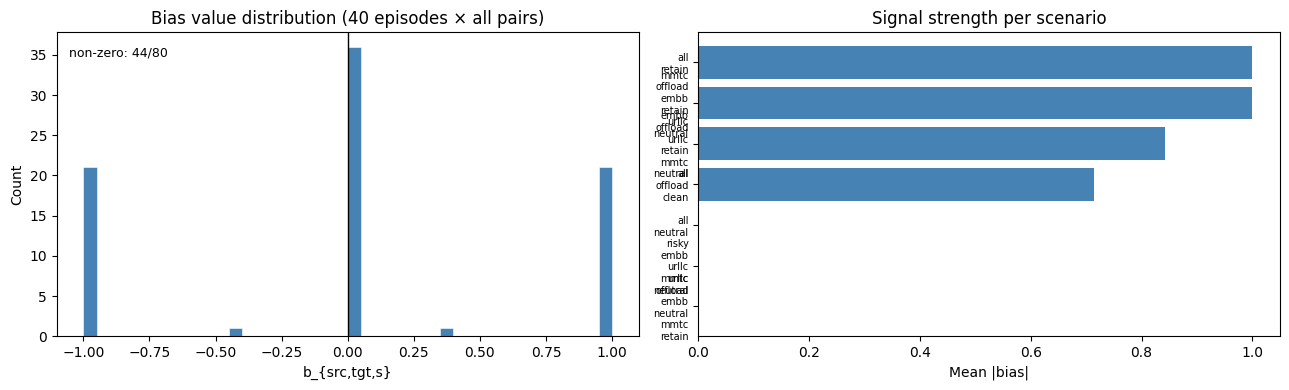

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of all bias values
ax = axes[0]
ax.hist(all_vals, bins=40, color='steelblue', edgecolor='white', lw=0.4)
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('b_{src,tgt,s}'); ax.set_ylabel('Count')
ax.set_title(f'Bias value distribution ({n_episodes} episodes × all pairs)')
ax.text(0.02, 0.92, f'non-zero: {sum(v!=0 for v in all_vals)}/{len(all_vals)}',
        transform=ax.transAxes, fontsize=9)

# Mean |bias| per scenario (sorted)
ax = axes[1]
by_scenario = {}
for r in results:
    name = r['scenario']
    by_scenario.setdefault(name, []).extend(np.abs(r['bias_vals']))
names = sorted(by_scenario, key=lambda k: np.mean(by_scenario[k]))
means = [np.mean(by_scenario[n]) for n in names]
ax.barh(range(len(names)), means, color='steelblue')
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n.replace('_', '\n') for n in names], fontsize=7)
ax.set_xlabel('Mean |bias|'); ax.set_title('Signal strength per scenario')

plt.tight_layout()
plt.show()

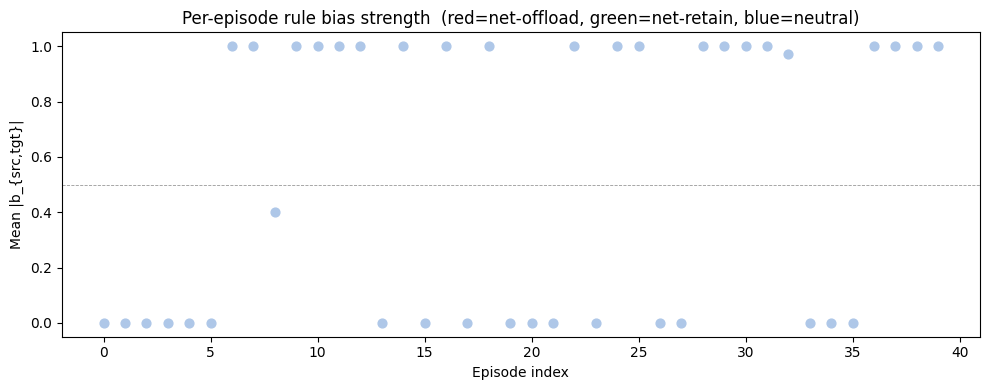

In [12]:
# Scatter: mean_abs_bias vs scenario, colour by whether mostly offload or retain
fig, ax = plt.subplots(figsize=(10, 4))

for i, r in enumerate(results):
    vals_arr = np.array(r['bias_vals'])
    mean_val = vals_arr.mean() if len(vals_arr) else 0
    color = '#d62728' if mean_val < -0.1 else ('#2ca02c' if mean_val > 0.1 else '#aec7e8')
    ax.scatter(i, r['mean_abs'], color=color, s=40, zorder=3)

ax.set_xlabel('Episode index'); ax.set_ylabel('Mean |b_{src,tgt}|')
ax.set_title('Per-episode rule bias strength  (red=net-offload, green=net-retain, blue=neutral)')
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color='k', lw=0.6, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Summary

| Property | Old binary rule | New proportional rule |
|---|---|---|
| Output range | {−1, 0, +1} | (−1, 1) continuous |
| Offload trigger | `src>0.75 AND tgt<0.75` | any |diff| ≥ deadband with sufficient src load |
| Retain trigger | `src<0.45` | src lighter than tgt by deadband |
| Slice-aware | No | Yes (URLLC: tighter; mMTC: looser) |
| Gradient for TD3 | None | Continuous — agent learns magnitude, not just direction |